In [146]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

## Data Importing

In [147]:
file_path = "./data/raw/Energy_consumption.csv"


df = pd.read_csv(Path(file_path))
df.head(5)

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB


## Data Preprocessing

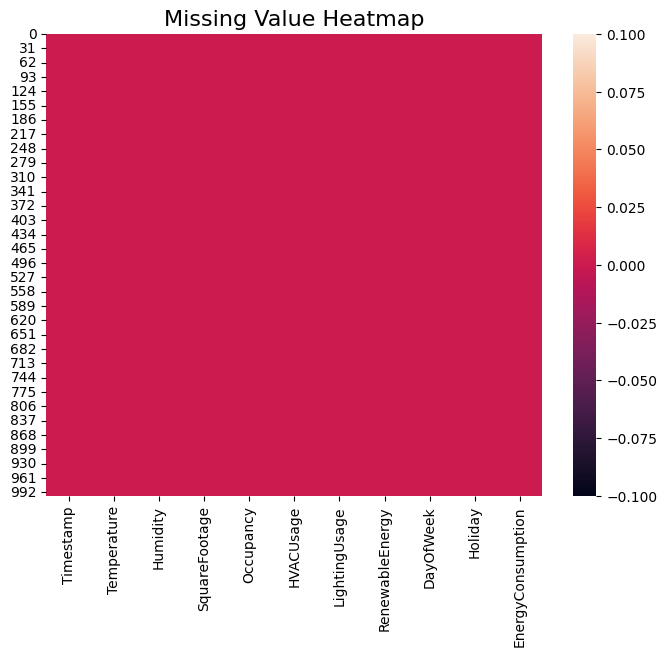

In [149]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isna())
plt.title("Missing Value Heatmap", fontsize=16)
plt.show()

In [150]:
#Date time conversion
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
#Time feature
df['Num_DayOfWeek'] = df['Timestamp'].dt.dayofweek
df["DayOfWeek"] = df["Timestamp"].dt.day_name()
df['Holiday'] = df['Num_DayOfWeek'].apply(lambda x: "Yes" if x >= 5 else "No")

df['hour'] = df['Timestamp'].dt.hour
df['month'] = df['Timestamp'].dt.month
df

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption,Num_DayOfWeek,hour,month
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Saturday,Yes,75.364373,5,0,1
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,Yes,83.401855,5,1,1
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Saturday,Yes,78.270888,5,2,1
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Saturday,Yes,56.519850,5,3,1
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Saturday,Yes,70.811732,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2022-02-11 11:00:00,28.619382,48.850160,1080.087000,5,Off,Off,21.194696,Friday,No,82.306692,4,11,2
996,2022-02-11 12:00:00,23.836647,47.256435,1705.235156,4,Off,On,25.748176,Friday,No,66.577320,4,12,2
997,2022-02-11 13:00:00,23.005340,48.720501,1320.285281,6,Off,On,0.297079,Friday,No,72.753471,4,13,2
998,2022-02-11 14:00:00,25.138365,31.306459,1309.079719,3,On,Off,20.425163,Friday,No,76.950389,4,14,2


## Data Exploratory

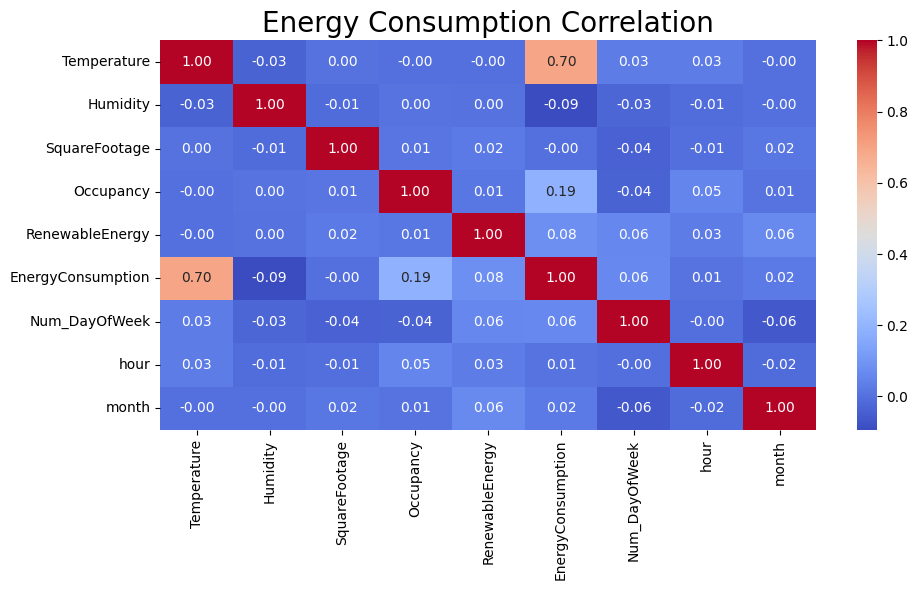

In [151]:
plt.figure(figsize=(10, 6))

corr = df.corr(numeric_only=True)
sns.heatmap(
    corr, 
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
    )
plt.title("Energy Consumption Correlation", fontsize=20)
plt.tight_layout()
plt.show()


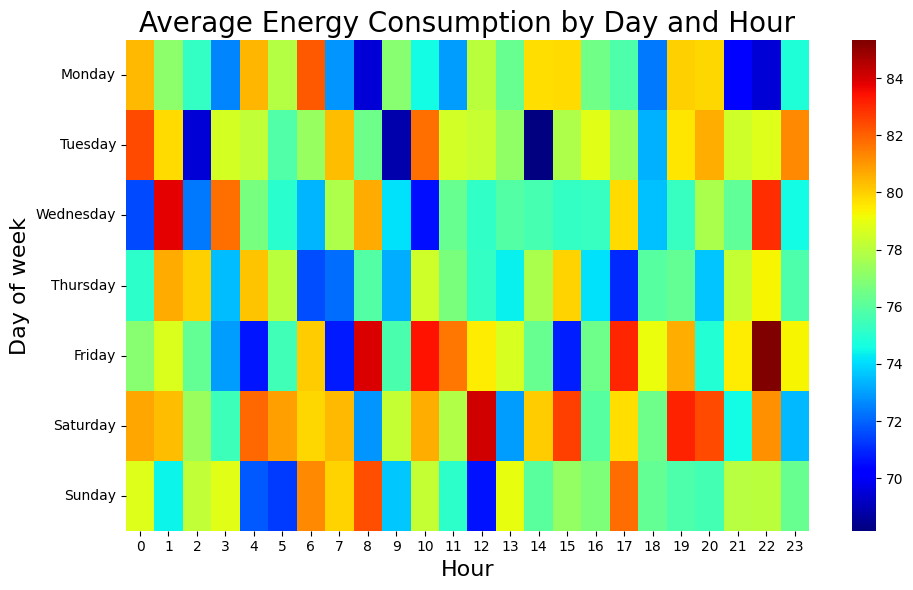

In [152]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

heatmap = df.pivot_table(
    index='DayOfWeek',
    columns='hour',
    values='EnergyConsumption',
    aggfunc='mean'
).reindex(day_order)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap, cmap="jet")
plt.title("Average Energy Consumption by Day and Hour", fontsize=20)
plt.ylabel("Day of week", fontsize=16)
plt.xlabel("Hour", fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\LC\AppData\Local\Temp\ipykernel_39644\4212269771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='DayOfWeek', y='EnergyConsumption', order=day_order, legend=False, palette='viridis')


Text(0, 0.5, 'Energy Consumption')

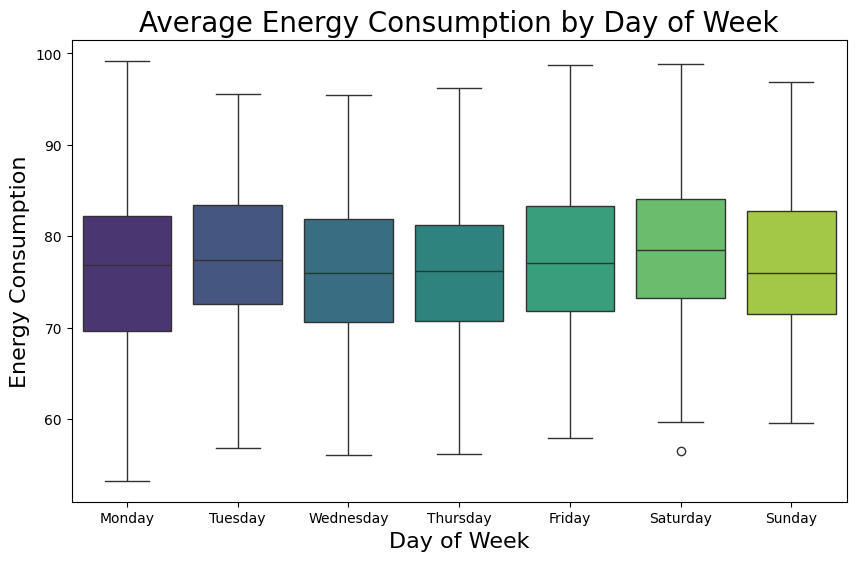

In [160]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='DayOfWeek', y='EnergyConsumption', order=day_order, legend=False, palette='viridis')
plt.title("Average Energy Consumption by Day of Week", fontsize=20)
plt.xlabel("Day of Week", fontsize=16)
plt.ylabel("Energy Consumption", fontsize=16)

Text(0.5, 0, 'Temperature')

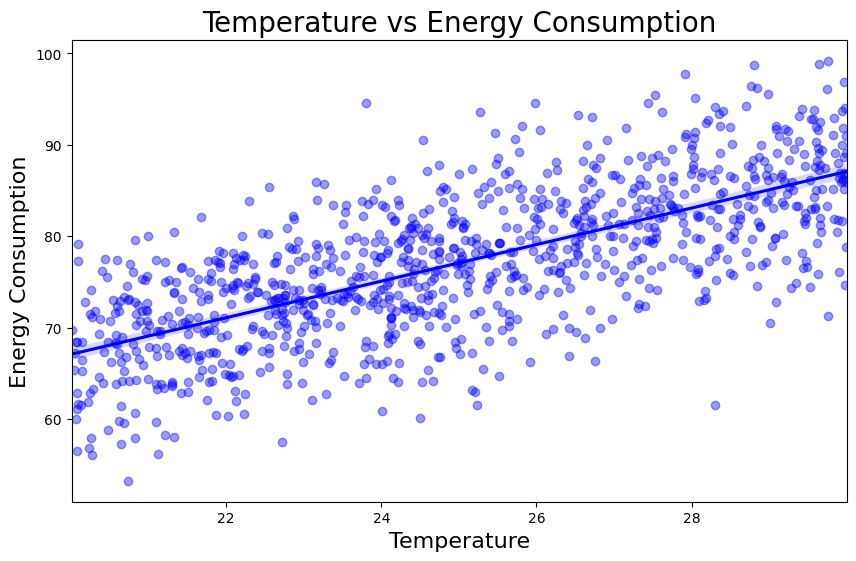

In [154]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Temperature', y='EnergyConsumption', scatter_kws={"alpha": 0.4}, color='blue')
plt.title("Temperature vs Energy Consumption", fontsize=20)
plt.xlim(df['Temperature'].min(), df["Temperature"].max())
plt.ylabel("Energy Consumption", fontsize=16)
plt.xlabel("Temperature", fontsize=16)

Text(0.5, 0, 'Humidity ')

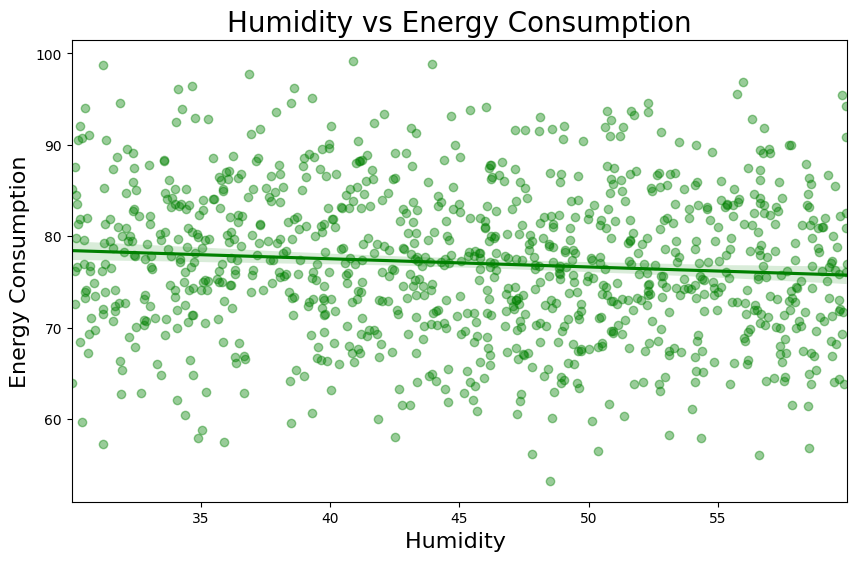

In [155]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Humidity', y='EnergyConsumption', scatter_kws={"alpha": 0.4}, color='green')
plt.title("Humidity vs Energy Consumption", fontsize=20)
plt.xlim(df['Humidity'].min(), df["Humidity"].max())
plt.ylabel("Energy Consumption", fontsize=16)
plt.xlabel("Humidity ", fontsize=16)

In [156]:
data = df.copy()
data = data.sort_values("Timestamp")

#One-hot encoding
data = pd.get_dummies(data, columns=[
    "HVACUsage", "LightingUsage", 'DayOfWeek', 'Holiday'
], drop_first=True)

#Lag feature
data['lag_1'] = data['EnergyConsumption'].shift(1)
data['lag_2'] = data['EnergyConsumption'].shift(2)
data['lag_24'] = data['EnergyConsumption'].shift(24)

#Rolling feature
data['rolling_mean'] = data['EnergyConsumption'].rolling(24).mean()

data = data.dropna()

data.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption,Num_DayOfWeek,hour,month,...,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,Holiday_Yes,lag_1,lag_2,lag_24,rolling_mean
24,2022-01-02 00:00:00,26.729367,46.194088,1533.887523,8,18.581034,87.841645,6,0,1,...,False,True,False,False,False,True,78.394208,70.235228,75.364373,77.230628
25,2022-01-02 01:00:00,22.575924,57.749572,1040.206215,8,8.906946,72.929844,6,1,1,...,False,True,False,False,False,True,87.841645,78.394208,83.401855,76.794294
26,2022-01-02 02:00:00,27.011513,52.637572,1701.255341,9,24.051355,86.669094,6,2,1,...,False,True,False,False,False,True,72.929844,87.841645,78.270888,77.144220
27,2022-01-02 03:00:00,26.570001,43.330312,1126.062798,7,2.943403,80.411428,6,3,1,...,False,True,False,False,False,True,86.669094,72.929844,56.519850,78.139702
28,2022-01-02 04:00:00,21.820078,56.855188,1289.616033,3,25.513775,64.212098,6,4,1,...,False,True,False,False,False,True,80.411428,86.669094,70.811732,77.864717


## Training

In [157]:
X = data.drop(['EnergyConsumption', 'Timestamp'], axis=1)
y = data['EnergyConsumption']

tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(max_depth=5),
    "RandomForest": RandomForestRegressor(n_estimators=100),
    "GradientBoosting": GradientBoostingRegressor(),
    "SVR": SVR()
}

X.dtypes, y.dtypes

(Temperature            float64
 Humidity               float64
 SquareFootage          float64
 Occupancy                int64
 RenewableEnergy        float64
 Num_DayOfWeek            int32
 hour                     int32
 month                    int32
 HVACUsage_On              bool
 LightingUsage_On          bool
 DayOfWeek_Monday          bool
 DayOfWeek_Saturday        bool
 DayOfWeek_Sunday          bool
 DayOfWeek_Thursday        bool
 DayOfWeek_Tuesday         bool
 DayOfWeek_Wednesday       bool
 Holiday_Yes               bool
 lag_1                  float64
 lag_2                  float64
 lag_24                 float64
 rolling_mean           float64
 dtype: object,
 dtype('float64'))

In [158]:
results = []
for name, model in models.items():
    mae_list = []
    rmse_list = []
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)

        mae_list.append(mae)
        rmse_list.append(rmse)

    results.append({
        "Model": name,
        "MAE": np.mean(np.array(mae_list)),
        "RMSE": np.mean(np.array(rmse_list))
    })

results_df = pd.DataFrame(results).sort_values("RMSE", ascending=True)
results_df


,Model,MAE,RMSE
1,Ridge,4.163279,5.216980
0,Linear,4.171647,5.232077
4,RandomForest,4.360811,5.439440
5,GradientBoosting,4.415432,5.521964
2,Lasso,4.456821,5.534670
3,DecisionTree,5.117871,6.422345
6,SVR,6.602870,8.154006
